In [1]:
import os
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

from tqdm.auto import tqdm
import re

from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

## Reading Dataset

In [2]:
dataset_path = os.path.join('..', 'datasets', 'archive')

comments = pd.read_csv(
    os.path.join(dataset_path, 'UScomments.csv'),
    on_bad_lines='skip',
    encoding='utf-8',
    low_memory=False
)
videos = pd.read_csv(
    os.path.join(dataset_path, 'USvideos.csv'), 
    on_bad_lines='skip', 
    encoding='utf-8')

In [3]:
display(comments.head()) # Display the first few rows of the dataset
display(comments.info()) # Display the information about the dataset

,video_id,comment_text,likes,replies
0,XpVt6Z1Gjjo,Logan Paul it's yo big day ‼️‼️‼️,4,0
1,XpVt6Z1Gjjo,I've been following you from the start of your...,3,0
2,XpVt6Z1Gjjo,Say hi to Kong and maverick for me,3,0
3,XpVt6Z1Gjjo,MY FAN . attendance,3,0
4,XpVt6Z1Gjjo,trending 😉,3,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691400 entries, 0 to 691399
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   video_id      691400 non-null  object
 1   comment_text  691374 non-null  object
 2   likes         691400 non-null  object
 3   replies       691400 non-null  object
dtypes: object(4)
memory usage: 21.1+ MB


None

In [4]:
comments.loc[comments['comment_text'].isna()]  # Filter rows based on condition

,video_id,comment_text,likes,replies
1417,1L7JFN7tQLs,NaN,0,0
76134,7YAAyUFL1GQ,NaN,0,0
215218,KUCHBBCj77I,NaN,0,0
234226,KUCHBBCj77I,NaN,0,0
306019,s3Hk_lDw5yo,NaN,0,0
332811,zrOHeEA14kQ,NaN,0,0
357506,zmg9tVaMVd4,NaN,0,0
379582,zmg9tVaMVd4,NaN,0,0
403013,9eea7_7OBZQ,NaN,0,0
425238,6l5P7jHUcjI,NaN,0,0


In [5]:
comments.dropna(inplace=True) # Drop rows with null values

In [6]:
comments.info() # Check the data types and null values

<class 'pandas.core.frame.DataFrame'>
Index: 691374 entries, 0 to 691399
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   video_id      691374 non-null  object
 1   comment_text  691374 non-null  object
 2   likes         691374 non-null  object
 3   replies       691374 non-null  object
dtypes: object(4)
memory usage: 26.4+ MB


## Splitting into Training and Test Set

In [7]:
# Split the dataset
train_comments, test_comments = train_test_split(comments, test_size=0.2, random_state=42)
comments_dummy = comments.copy() # Create a copy of the comments DataFrame to use for dummy model (TextBlob)

## Text Cleaning & Tokenization

In [8]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to C:\Users\New
[nltk_data]     Owner\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\New
[nltk_data]     Owner\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\New
[nltk_data]     Owner\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [9]:
def clear_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r"(@\S+|#\S+|http\S+|[^a-zA-Z\s])", " ", text)  # Combine regex patterns to remove mentions, hashtags, URLs, and special characters
    text = re.sub(r"\s+", " ", text).strip()  # Replace multiple spaces with a single space and strip leading/trailing spaces
    return text

In [10]:
train_comments['comment_text'] = train_comments['comment_text'].astype(str).apply(clear_text).apply(word_tokenize)
test_comments['comment_text'] = test_comments['comment_text'].astype(str).apply(clear_text).apply(word_tokenize)
comments_dummy['comment_text'] = comments_dummy['comment_text'].astype(str).apply(clear_text).apply(word_tokenize)

## Stop Word Removal/Lemmatization

In [11]:
stop_words = set(stopwords.words('english')) # Set of English stop words
lemmatizer = WordNetLemmatizer() # Initialize the lemmatizer

# Remove stop words and apply lemmatization to the tokenized text
train_comments['tokenized_text'] = train_comments['comment_text'].apply(lambda tokens: [word for word in tokens if word not in stop_words])
train_comments['tokenized_text'] = train_comments['comment_text'].apply(lambda tokens: [lemmatizer.lemmatize(word) for word in tokens])

test_comments['tokenized_text'] = test_comments['comment_text'].apply(lambda tokens: [word for word in tokens if word not in stop_words])
test_comments['tokenized_text'] = test_comments['comment_text'].apply(lambda tokens: [lemmatizer.lemmatize(word) for word in tokens])

comments_dummy['tokenized_text'] = comments_dummy['comment_text'].apply(lambda tokens: [word for word in tokens if word not in stop_words])
comments_dummy['tokenized_text'] = comments_dummy['comment_text'].apply(lambda tokens: [lemmatizer.lemmatize(word) for word in tokens])

In [12]:
train_comments['tokenized_text'] = train_comments['tokenized_text'].apply(lambda tokens: ' '.join(tokens))
test_comments['tokenized_text'] = test_comments['tokenized_text'].apply(lambda tokens: ' '.join(tokens))
comments_dummy['tokenized_text'] = comments_dummy['tokenized_text'].apply(lambda tokens: ' '.join(tokens))

## Creating Like-to-Dislike Ratio

In [13]:
total_interactions = videos['likes'] + videos['dislikes'] # Calculate total interactions
videos['l_d_ratio'] = videos['likes'] / total_interactions # Calculate the like-dislike ratio
videos.head(10)

,video_id,title,channel_title,category_id,tags,views,likes,dislikes,comment_total,thumbnail_link,date,l_d_ratio
0,XpVt6Z1Gjjo,1 YEAR OF VLOGGING -- HOW LOGAN PAUL CHANGED Y...,Logan Paul Vlogs,24,logan paul vlog|logan paul|logan|paul|olympics...,4394029,320053,5931,46245,https://i.ytimg.com/vi/XpVt6Z1Gjjo/default.jpg,13.09,0.981806
1,K4wEI5zhHB0,iPhone X — Introducing iPhone X — Apple,Apple,28,Apple|iPhone 10|iPhone Ten|iPhone|Portrait Lig...,7860119,185853,26679,0,https://i.ytimg.com/vi/K4wEI5zhHB0/default.jpg,13.09,0.874471
2,cLdxuaxaQwc,My Response,PewDiePie,22,[none],5845909,576597,39774,170708,https://i.ytimg.com/vi/cLdxuaxaQwc/default.jpg,13.09,0.935471
3,WYYvHb03Eog,Apple iPhone X first look,The Verge,28,apple iphone x hands on|Apple iPhone X|iPhone ...,2642103,24975,4542,12829,https://i.ytimg.com/vi/WYYvHb03Eog/default.jpg,13.09,0.846123
4,sjlHnJvXdQs,iPhone X (parody),jacksfilms,23,jacksfilms|parody|parodies|iphone|iphone x|iph...,1168130,96666,568,6666,https://i.ytimg.com/vi/sjlHnJvXdQs/default.jpg,13.09,0.994158
5,cMKX2tE5Luk,The Disaster Artist | Official Trailer HD | A24,A24,1,a24|a24 films|a24 trailers|independent films|t...,1311445,34507,544,3040,https://i.ytimg.com/vi/cMKX2tE5Luk/default.jpg,13.09,0.984480
6,8wNr-NQImFg,"The Check In: HUD, Ben Carson and Hurricanes",Late Night with Seth Meyers,23,Late night|Seth Meyers|check in|hud|Ben Carson...,666169,9985,297,1071,https://i.ytimg.com/vi/8wNr-NQImFg/default.jpg,13.09,0.971115
7,_HTXMhKWqnA,iPhone X Impressions & Hands On!,Marques Brownlee,28,iPhone X|iphone x|iphone 10|iPhone X impressio...,1728614,74062,2180,15297,https://i.ytimg.com/vi/_HTXMhKWqnA/default.jpg,13.09,0.971407
8,_ANP3HR1jsM,ATTACKED BY A POLICE DOG!!,RomanAtwoodVlogs,22,Roman Atwood|Roman|Atwood|roman atwood vlogs|f...,1338533,69687,678,5643,https://i.ytimg.com/vi/_ANP3HR1jsM/default.jpg,13.09,0.990365
9,zgLtEob6X-Q,Honest Trailers - The Mummy (2017),Screen Junkies,1,screenjunkies|screen junkies|screenjunkies new...,1056891,29943,878,4046,https://i.ytimg.com/vi/zgLtEob6X-Q/default.jpg,13.09,0.971513


## Creating Positive-to-Negative Comments Ratio

In [14]:
from textblob import TextBlob
def get_sentiment(text):
    analysis = TextBlob(text)
    polarity = analysis.sentiment.polarity  # -1 (negative) to 1 (positive)

    # Binary classification
    sentiment_class = "positive" if polarity > 0 else "negative"

    return sentiment_class

In [15]:
comments_dummy.drop(columns=['comment_text'], inplace=True) # Drop the original comment text column

In [16]:
comments_dummy['sentiment_ratio'] = comments_dummy['tokenized_text'].apply(get_sentiment) # Apply the sentiment function to the tokenized text
comments_dummy.head(10) # Display the first 10 rows of the comments_dummy DataFrame

,video_id,likes,replies,tokenized_text,sentiment_ratio
0,XpVt6Z1Gjjo,4,0,logan paul it s yo big day,negative
1,XpVt6Z1Gjjo,3,0,i ve been following you from the start of your...,negative
2,XpVt6Z1Gjjo,3,0,say hi to kong and maverick for me,negative
3,XpVt6Z1Gjjo,3,0,my fan attendance,negative
4,XpVt6Z1Gjjo,3,0,trending,negative
5,XpVt6Z1Gjjo,3,0,on trending ayyeeeee,negative
6,XpVt6Z1Gjjo,4,0,the end though,negative
7,XpVt6Z1Gjjo,3,0,trending,negative
8,XpVt6Z1Gjjo,3,0,happy one year vlogaversary,positive
9,XpVt6Z1Gjjo,0,0,you and your shit brother may have single hand...,negative


In [17]:
sentiment_count = comments_dummy.groupby('video_id')['sentiment_ratio'].value_counts().unstack().fillna(0) # Count the occurrences of each sentiment class
sentiment_count['ratio'] = sentiment_count['positive'] / (sentiment_count['positive'] + sentiment_count['negative']) # Calculate the sentiment ratio (normalized)

In [18]:
dummy_vid_stats = videos.merge(sentiment_count, on='video_id') # Merge the sentiment count with the videos DataFrame
dummy_vid_stats.dropna(inplace=True) # Drop rows with NaN values
dummy_vid_stats = dummy_vid_stats[['video_id', 'title', 'l_d_ratio', 'ratio']] # Select relevant columns

In [19]:
dummy_vid_stats.head() # Display the information about the dummy_vid_stats DataFrame

,video_id,title,l_d_ratio,ratio
0,XpVt6Z1Gjjo,1 YEAR OF VLOGGING -- HOW LOGAN PAUL CHANGED Y...,0.981806,0.310000
1,cLdxuaxaQwc,My Response,0.935471,0.349186
2,WYYvHb03Eog,Apple iPhone X first look,0.846123,0.355000
3,sjlHnJvXdQs,iPhone X (parody),0.994158,0.385000
4,cMKX2tE5Luk,The Disaster Artist | Official Trailer HD | A24,0.984480,0.418571


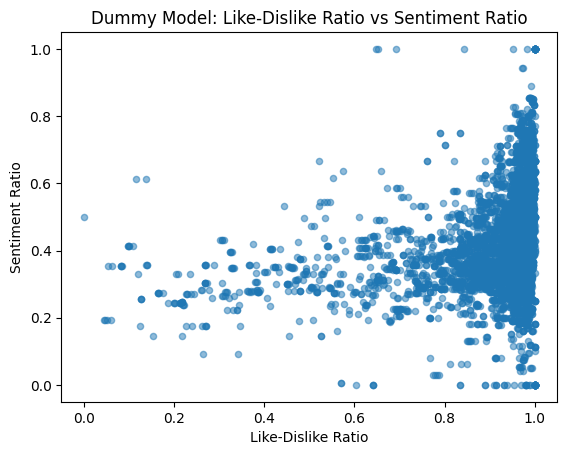

In [20]:
dummy_vid_stats.plot.scatter(x='l_d_ratio', y='ratio', alpha=0.5) # Scatter plot of like-dislike ratio vs sentiment ratio
plt.title('Dummy Model: Like-Dislike Ratio vs Sentiment Ratio') # Title of the plot
plt.xlabel('Like-Dislike Ratio') # X-axis label
plt.ylabel('Sentiment Ratio') # Y-axis label
plt.show() # Show the plot


In [21]:
dummy_vid_stats[['l_d_ratio', 'ratio']].corr() # Calculate the correlation between the like-dislike ratio and the sentiment ratio

,l_d_ratio,ratio
l_d_ratio,1.000000,0.278284
ratio,0.278284,1.000000


After analyzing the metrics for the listed YouTube videos, we observed a weak correlation between the Like-Dislike ratio and the Sentiment ratio. As a video accumulates more likes, the proportion of positive comments tends to increase.

This trend may be partially influenced by YouTube's algorithm—videos with higher engagement are more likely to appear in users' feeds, increasing visibility and the chance of receiving comments.

However, since the correlation is weak, the relationship between likes and comment sentiment is only marginal. Other underlying factors likely play a bigger role in this dynamic.

The key takeaway? Early on, you may see more likes than comments, but with consistent posting, positive engagement (including comments) should grow over time—though not all comments will be positive.

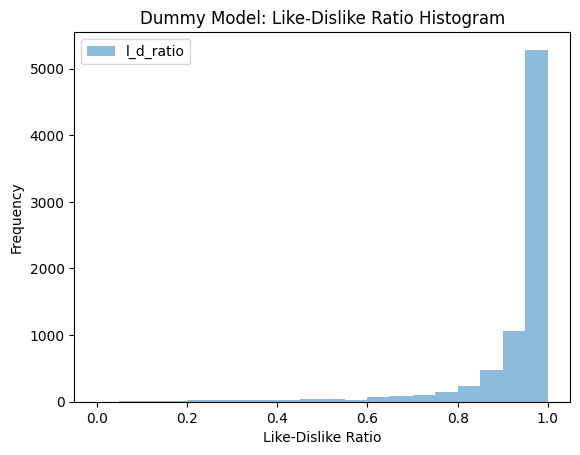

In [22]:
dummy_vid_stats.plot.hist(y='l_d_ratio', bins=20, alpha=0.5) # Histogram of the like-dislike ratio
plt.title('Dummy Model: Like-Dislike Ratio Histogram') # Title of the plot
plt.xlabel('Like-Dislike Ratio') # X-axis label
plt.ylabel('Frequency') # Y-axis label
plt.show() # Show the plot

## Model Training
---

In [23]:
# Apply the function to the 'tokenized_text' column
train_comments['sentiment_class'] = train_comments['tokenized_text'].apply(get_sentiment)

test_comments['sentiment_class'] = test_comments['tokenized_text'].apply(get_sentiment)

### TF-IDF & Logistic Regression

In [24]:
# Ensure the correct usage of TfidfVectorizer methods
vectorizer = TfidfVectorizer() # Initialize the vectorizer
X_train_vect = vectorizer.fit_transform(train_comments['tokenized_text']) # Fit and transform the training data
X_test_vect = vectorizer.transform(test_comments['tokenized_text']) # Transform the test data

In [25]:
# Target variable encoding
le = LabelEncoder() # Initialize the label encoder
y_train = le.fit_transform(train_comments['sentiment_class']) # Fit and transform the training data
y_test = le.transform(test_comments['sentiment_class']) # Transform the test data

In [26]:
log_model = LogisticRegression(class_weight='balanced',max_iter=200)  # Initialize the logistic regression model
log_model.fit(X_train_vect, y_train)  # Fit the model to the training data

# Make predictions on the test data
y_pred_encoded = log_model.predict(X_test_vect)  # Make predictions on the test data
y_pred = le.inverse_transform(y_pred_encoded)  # Decode the predictions back to the original labels

In [27]:
# Generate the classification report
report = classification_report(y_test, y_pred_encoded)
print(report)  # Print the classification report

              precision    recall  f1-score   support

           0       0.97      0.97      0.97     78145
           1       0.96      0.96      0.96     60130

    accuracy                           0.97    138275
   macro avg       0.97      0.97      0.97    138275
weighted avg       0.97      0.97      0.97    138275



Class imbalance is a common challenge in classification tasks, typically requiring manual correction through oversampling or undersampling. However, logistic regression, along with the latter model offers a built-in solution to address this issue innately, efficiently managing uneven class distributions without additional sampling steps.

## TF-IDF & Decision Tree Classifier

In [28]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)  # Initialize the decision tree model

# Fit the model to the training data
dt_model.fit(X_train_vect, y_train)  # Fit the model to the training data

# Make predictions on the test data
y_pred_dt_encoded = dt_model.predict(X_test_vect)  # Make predictions on the test data
y_pred_dt = le.inverse_transform(y_pred_dt_encoded)  # Decode the predictions back to the original labels

# Generate the classification report for Decision Tree
report_dt = classification_report(y_test, y_pred_dt_encoded)
print(report_dt)  # Print the classification report for Decision Tree

              precision    recall  f1-score   support

           0       0.98      0.97      0.98     78145
           1       0.97      0.97      0.97     60130

    accuracy                           0.97    138275
   macro avg       0.97      0.97      0.97    138275
weighted avg       0.97      0.97      0.97    138275



### Tf-IDF + LightGBM Classifier

In [ ]:
# Import the LightGBM library
import lightgbm as lgb

# Initialize the LightGBM Classifier
lgb_model = lgb.LGBMClassifier(class_weight='balanced', force_col_wise=True, random_state=42)  # Initialize the LightGBM model

# Fit the model to the training data
lgb_model.fit(X_train_vect, y_train)  # Fit the model to the training data

# Make predictions on the test data
y_pred_lgb_encoded = lgb_model.predict(X_test_vect)  # Make predictions on the test data
y_pred_lgb = le.inverse_transform(y_pred_lgb_encoded)  # Decode the predictions back to the original labels

# Generate the classification report for LightGBM
report_lgb = classification_report(y_test, y_pred_lgb_encoded)
print(report_lgb)  # Print the classification report for LightGBM

Note: you may need to restart the kernel to use updated packages.
[LightGBM] [Info] Number of positive: 241017, number of negative: 312082
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 18.310840 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 361687
[LightGBM] [Info] Number of data points in the train set: 553099, number of used features: 14182
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


c:\Users\New Owner\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.94      0.95      0.95     78145
           1       0.93      0.93      0.93     60130

    accuracy                           0.94    138275
   macro avg       0.94      0.94      0.94    138275
weighted avg       0.94      0.94      0.94    138275



After vectorizing the features and training the